# Hypothesis Testing in Business
In this project I try myself as an analyst for the GoFast scooter rental service. The company provided three datasets with data on service users, their rides over one year, and subscription pricing. I am asked to analyze user demographics and scooter usage patterns, and to determine the potential benefit of expanding the paid subscription for scooters.

# Data Description

Users table `users_go.csv`

- `user_id` — unique user ID.

- `name` — user name.

- `age` — age.

- `city` — city.

- `subscription_type` — subscription type: `free`, `ultra`.

Rides table `rides_go.csv`

- `user_id` — unique user ID.

- `distance` — distance in meters that the user traveled in the current session.

- `duration` — session duration in minutes, from when the user presses "Start ride" to when they press "End ride".

- `date` — ride date.

Subscriptions table `subscriptions_go.csv`

- `subscription_type` — subscription type.

- `minute_price` — price per minute for this plan.

- `start_ride_price` — price to start a ride.

- `subscription_fee` — monthly subscription fee.

---
## Task 1. Load the data
At the first step we will load all required data and review the table contents.

### Task 1.1 Import the pandas library

### Task 1.1 Read the data
Save the three CSV files into separate dataframes. Name them after the files with a `df_` prefix.

In [1]:
import pandas as pd

In [ ]:
df_users_go = pd.read_csv('...datasets/users_go.csv')
df_rides_go = pd.read_csv('...datasets/rides_go.csv')
df_subscriptions_go =pd.read_csv('...datasets/subscriptions_go.csv')

### Task 1.2 Print the first rows
Print the first five rows of each dataframe to review the contents.

In [3]:
df_users_go.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
df_rides_go.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
df_subscriptions_go.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


### Task 1.3 Count rows
Determine the number of rows in each of the three dataframes. This helps estimate data volume and spot anomalies, such as a very small number of records.

In [6]:
print(f'{len(df_users_go)} {len(df_rides_go)} {len(df_subscriptions_go)}')

1565 18068 2


---
## Task 2. Data review and preprocessing

Before analysis, it is important to verify data quality. We will take a few steps to understand the structure and fix potential issues in the tables.

### Task 2.1 Determine data types
In the `df_rides_go` dataframe, print the data types for each column using the `dtypes` attribute. This checks type correctness and prepares the data for further processing.

In [7]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date            str
dtype: object

### Task 2.2 Convert date format
Convert the `date` column in `df_rides_go` to pandas datetime using `pd.to_datetime()`.

In [8]:
df_rides_go['date']= pd.to_datetime(df_rides_go['date'])

### Task 2.3 Create a month column
Based on the `date` column, create a new column `month` with the month number. This is needed for grouping and seasonal analysis.

In [9]:
df_rides_go['month']= df_rides_go['date'].dt.month

### Task 2.4 Find duplicates and missing values
In the users dataframe `df_users_go`, determine the number of missing values and duplicates.

In [10]:
print(f'{df_users_go.isna().sum().sum()} {df_users_go.duplicated().sum()}')

0 31


### Task 2.5 Fill missing values and remove duplicates
Remove all duplicates.

In [11]:
df_users_go=df_users_go.drop_duplicates()

### Task 2.6 Round ride duration
In the rides dataframe `df_rides_go`, round `duration` to a whole number. Then cast this column to integer type `int`.

In [12]:
df_rides_go['duration']= round(df_rides_go['duration'])
df_rides_go['duration'] = df_rides_go['duration'].astype(dtype = 'int64')

---
## Task 3. Exploratory Data Analysis (EDA)
Exploratory data analysis is an essential part of an analyst's work. Here our goal is to visualize the service geography and demographics, and to better understand patterns in ride distances and durations.


### Task 3.1 Users by city.
Using the `df_users_go` dataframe, study the number of users in each city. Create and display a `pd.Series` named `users_by_city_count` with one column `count`, the total number of users per `city`, sorted in descending order.

In [13]:
import matplotlib.pyplot as plt

In [14]:
users_by_city_count=df_users_go['city'].value_counts()
users_by_city_count

city
Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: count, dtype: int64

### Task 3.2 Users by subscription type
Create and display a series `subscription_type_count` with the number of users for each `subscription_type`.

In [15]:
subscription_type_count=df_users_go['subscription_type'].value_counts()
subscription_type_count

subscription_type
free     835
ultra    699
Name: count, dtype: int64

### Task 3.3 Pie chart
Build a pie chart showing the share of users with `free` and `ultra` subscriptions. Call `plot()` on the `subscription_type_count` series with the argument needed for a pie chart.

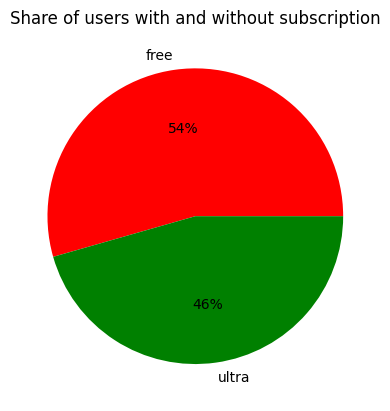

In [16]:
subscription_type_count.plot(
    kind='pie' ,
    title='Share of users with and without subscription',
    autopct= '%.0f%%',
    ylabel= '',
    colors = ['red','green']
)

plt.show()

### Task 3.4 Age histogram
Build a histogram of user ages `age`. Use the number of bins equal to the difference between the maximum and minimum ages.

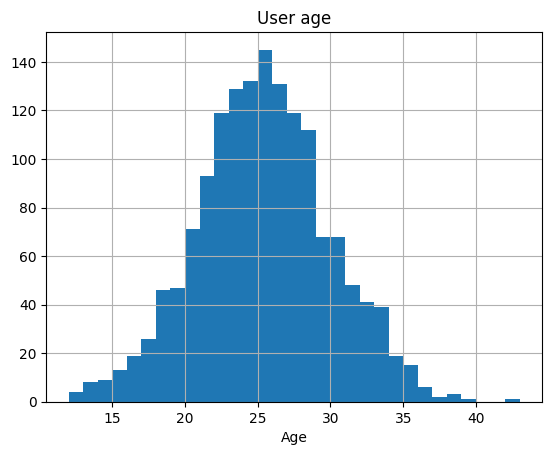

In [17]:
n_bins = max(df_users_go['age']) - min(df_users_go['age'])
df_users_go['age'].hist(
    bins = n_bins)

plt.title('User age')
plt.xlabel("Age")
plt.show()

### Task 3.5 Underage users
Calculate the share of underage users (age under 18).

In [18]:
users_under_18_ratio =  round((df_users_go['age']<18).sum()/ len(df_users_go) *100)
print(f'The share of underage scooter users is {users_under_18_ratio}%.')

The share of underage scooter users is 5%.


### Task 3.6 Ride duration characteristics
Ride duration is an important metric for the scooter rental service. If average ride duration is too high, scooters will wear out faster. If it is too low, users may be dissatisfied with the service.

In this task, use descriptive statistics to study ride duration:
1 Calculate the mean and standard deviation of ride duration.
2 Calculate the 25th and 75th percentiles of ride duration.

In [19]:
duration_mean = round(df_rides_go['duration'].mean())

duration_std = round(df_rides_go['duration'].std())

duration_pct25 = round(df_rides_go['duration'].quantile(0.25))

duration_pct75 = round( df_rides_go['duration'].quantile(0.75))

print(f'Average ride duration is {duration_mean} minutes with a standard deviation of {duration_std}. Most rides take from {duration_pct25} to {duration_pct75} minutes.')

Average ride duration is 18 minutes with a standard deviation of 6. Most rides take from 14 to 22 minutes.


---
## Task 4. Merge data


### Task 4.1 Merge users and rides tables
Merge the dataframes with user info `df_users_go` and rides `df_rides_go`. Name the resulting dataframe `df`.

In [20]:
df = df_users_go.merge(df_rides_go, on = 'user_id',how = 'left')
df

,user_id,name,age,city,subscription_type,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8
...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,20,2021-11-04,11
18064,1534,Альберт,25,Краснодар,free,2840.423057,21,2021-11-16,11
18065,1534,Альберт,25,Краснодар,free,3826.185507,18,2021-11-18,11
18066,1534,Альберт,25,Краснодар,free,2902.308661,17,2021-11-27,11


### Task 4.2 Join subscription info
Join the resulting dataframe `df` with subscription info from `df_subscriptions_go`.


In [21]:
df = df.merge(df_subscriptions_go,how ='left', on = 'subscription_type')

### Task 4.3 Size of the merged dataframe
For a final check, display the first five rows of `df` and the number of rows and columns. This ensures no records were lost during the merge.

In [ ]:
display(df)

n_rows, n_cols = df.shape
print(f'The merged dataframe has {n_rows} rows and {n_cols} columns.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,20,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,21,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,18,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,17,2021-11-27,11,8,50,0


The merged dataframe has 18068 rows and 12 columns.


### Task 4.4 Separate dataframes for subscribed and free users
Create two helper dataframes from `df`: one for users with subscription `df_ultra` and one for users without subscription `df_free`. These will be used to compare behavior and test hypotheses.

In [23]:
df_ultra = df[df['subscription_type']=='ultra']
df_free = df[df['subscription_type'] == 'free']

### Task 4.5 Ride duration histogram for both groups
On one chart, plot the histogram of ride duration `duration` for users with and without subscriptions.


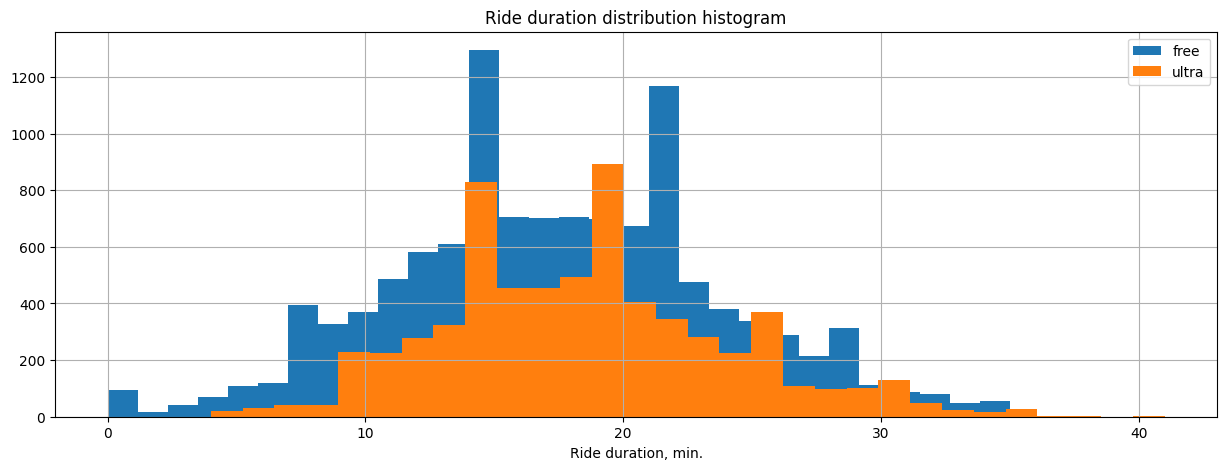

Average ride duration for free users is 17 min, and for subscribed users is 19 min


In [24]:
# Histogram of ride duration for subscribed and free users
plt.figure(figsize=(15, 5))
df_free['duration'].hist(
    bins = 30,
    label = 'free',
)
df_ultra['duration'].hist(
    bins = 30,
    label='ultra')
plt.xlabel('Ride duration, min.')
plt.title('Ride duration distribution histogram')
plt.legend()
plt.show()

# Calculate and display average ride duration for subscribed and free users
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Average ride duration for free users is {mean_duration_free} min, and for subscribed users is {mean_duration_ultra} min')

---
## Task 5. Revenue calculation
Ride counts and durations are merged with pricing, so we can now calculate a key business metric: revenue.

### Task 5.1 Group data by required columns
Group the data by: `user_id`, `name`, `subscription_type`, `month`. Perform grouping in dataframe `df_gp`. In `df_gp`, keep the original column order for aggregation.


In [25]:
df_gp = df.groupby(['user_id', 'name' ,'subscription_type', 'month'], as_index=False)

### Task 5.2 Calculate aggregated metrics
Create a new dataframe `df_agg`. For each group, compute and add the following aggregated values using `agg()`:
- `total_distance` — sum of `distance`.
- `total_duration` — sum of `duration`.
- `rides_count` — number of elements in `duration`.
- `subscription_type` — first value in the group for `subscription_type`.
- `minute_price` — first value in the group for `minute_price`.
- `start_ride_price` — first value in the group for `start_ride_price`.
- `subscription_fee` — first value in the group for `subscription_fee`.

In [26]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration= ('duration', 'sum'),
    rides_count= ('duration', 'count') ,
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
)

### Task 5.3 Function to calculate revenue
Create a function `calculate_monthly_revenue(row)` to calculate monthly revenue using:

`monthly_revenue` = `start_ride_price` * `rides_count` + `minute_price` * `total_duration` + `subscription_fee`

The function takes one dataframe row `row` as input.

Where:
- `start_ride_price * rides_count` — revenue from starting rides.
- `minute_price * total_duration` — revenue from ride time.
- `subscription_fee` — fixed subscription revenue.

In [27]:
def calculate_monthly_revenue(row):
    start_ride_price = row['start_ride_price']
    rides_count = row['rides_count']
    minute_price = row['minute_price']
    total_duration = row['total_duration']
    subscription_fee = row['subscription_fee']
    
    monthly_revenue = (start_ride_price * rides_count) + (minute_price * total_duration) + subscription_fee
    return monthly_revenue

### Task 5.4 Create monthly revenue per user column
Create a new column `monthly_revenue` with monthly revenue per user by applying `calculate_monthly_revenue(row)` to each row of `df_agg`.

In [28]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

### Task 5.5 Find the user with maximum revenue
Examine the revenue values. Find the user with the maximum total revenue over the observation period and print `user_id`, name, month, ride count, and revenue for each month.

In [ ]:
top_user_id = df_agg.groupby('user_id')['monthly_revenue'].sum().idxmax()

target_columns = ['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']
result = df_agg[df_agg['user_id'] == top_user_id][target_columns]

result

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


---
## Task 6. Hypothesis testing

### Task 6.1 Helper function for interpreting results
Write a helper function `print_stattest_results(p_value, alpha)` that interprets statistical test results based on the p-value and a significance level (alpha). The function decides whether to accept the alternative hypothesis or keep the null hypothesis.

The function has two parameters:
- `p_value` (type `float`) — the p-value from the test.
- `alpha` (type `float`, optional, default `alpha = 0.05`) — significance level used as the threshold for rejecting the null hypothesis.


In [30]:
import scipy.stats as st

In [31]:
def print_stattest_results(p_value: float, alpha: float = 0.05):
    if p_value < alpha:
        print(f"p_value={p_value} is below the critical level alpha={alpha}. Accept the alternative hypothesis.")
    else:
        print(f"p_value={p_value} is above the critical level alpha={alpha}. The null hypothesis cannot be rejected.")

print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

p_value=0.0001 is below the critical level alpha=0.05. Accept the alternative hypothesis.
p_value=0.1 is above the critical level alpha=0.05. The null hypothesis cannot be rejected.


### Task 6.2 Ride duration for subscribed vs free users

It is important to understand whether subscribed users spend more time riding. Formulate the hypotheses:
- Null hypothesis (H0): The average ride time is the same for subscribed and non-subscribed users.
- Alternative hypothesis (H1): The average ride time for subscribed users is higher than for non-subscribed users.

To test this hypothesis:
1. Use the non-aggregated data from `df_ultra` and `df_free` created earlier.
2. Use ride duration `duration` for subscribers and non-subscribers separately.
3. Compute the `p_value` for the selected hypothesis using `scipy.stats` and a one-sided t-test.
4. Call `print_stattest_results(p_value, alpha)` with the computed `p_value`.
5. Also compute the mean ride duration for `ultra` and `free`, rounded to two decimals using `round()`.

In [32]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']

results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value)

ultra_mean_duration = round(ultra_duration.mean(), 2)
free_mean_duration = round(free_duration.mean(), 2)

print(f'Average ride duration for Ultra: {ultra_mean_duration}')
print(f'Average ride duration for Free: {free_mean_duration}')

p_value=3.1600689435611813e-35 is below the critical level alpha=0.05. Accept the alternative hypothesis.
Average ride duration for Ultra: 18.55
Average ride duration for Free: 17.39


### Task 6.3 Ride distance: above or below the critical value

Analyze another important product hypothesis. A ride distance of 3130 meters is considered optimal in terms of scooter wear. Can we say that the distance traveled by subscribed users in a single ride is greater than 3130 meters?

Formulate the hypotheses:

- Null hypothesis (H0): The average ride distance for subscribed users equals 3130 m.

- Alternative hypothesis (H1): The average ride distance for subscribed users is greater than 3130 m.

To test this hypothesis:

1. Use the non-aggregated ride data for subscribed users from `df_ultra`.

2. Use ride distance `distance`.

3. Compute the `p_value` using `scipy.stats` and a one-sided t-test.

4. Call `print_stattest_results(p_value, alpha)` with the computed `p_value`.

In [33]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']

results = st.ttest_1samp(ultra_distance, null_hypothesis, alternative='greater')
p_value = results.pvalue

print_stattest_results(p_value)

p_value=0.9195368847849785 is above the critical level alpha=0.05. The null hypothesis cannot be rejected.


### Task 6.4 Revenue from subscribed vs free users
Test the hypothesis that revenue from subscribed users is higher than revenue from free users.

Formulate the hypotheses:

- Null hypothesis (H0): The average monthly revenue is the same for subscribed and non-subscribed users.
- Alternative hypothesis (H1): The average monthly revenue for subscribed users is higher than for non-subscribed users.

To test this hypothesis:
1. Use the aggregated data from `df_agg` prepared in Task 5.
2. Use monthly revenue per user, `monthly_revenue`.
3. Compute the `p_value` using `scipy.stats` and a one-sided t-test.
4. Call `print_stattest_results(p_value, alpha)` with the computed `p_value`.
5. Also compute the average revenue for `ultra` and `free`

In [34]:
revenue_ultra = df_agg[df_agg['subscription_type'] == 'ultra']['monthly_revenue']
revenue_free = df_agg[df_agg['subscription_type'] == 'free']['monthly_revenue']

results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue

print_stattest_results(p_value)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Average revenue for Ultra subscribers {mean_revenue_ultra} rub')
print(f'Average revenue for Free subscribers {mean_revenue_free} rub')

p_value=1.7274069878387966e-37 is below the critical level alpha=0.05. Accept the alternative hypothesis.
Average revenue for Ultra subscribers 359 rub
Average revenue for Free subscribers 322 rub


---
## Task 7. Distributions

The company has an idea to offer an extra discount to subscribers who take long rides longer than 30 minutes. We need to estimate the share of such rides.
Since we do not have access to all ride data, it was decided to model ride duration using a normal distribution with the sample mean and standard deviation from the available ride data.

### Task 7.1 Compute sample mean and standard deviation

1. Compute the mean ride duration and store it in `mu`.
2. Compute the standard deviation of `duration` and store it in `sigma`.
3. Set `target_time` to `30`. This variable will be used to compute the probability.

In [ ]:
mu = df_ultra['duration'].mean()

sigma = df_ultra['duration'].std()

target_time = 30

print(f"Average ride duration {round(mu, 1)}, standard deviation {round(sigma, 1)}.")

Average ride duration 18.5, standard deviation 5.6.


### Task 7.2 Compute the CDF value at a point
If we compute the value of the cumulative distribution function (CDF) at a point, we can find the probability that a random variable is less than or equal to that value. To answer the question about rides longer than 30 minutes, we need the CDF.

1. Use `norm()` from SciPy to create a normal distribution with parameters `mu` and `sigma`.

2. Apply `cdf()` to the target time `target_time` to get the probability that the random variable is less than or equal to it. Store the result in `prob`, rounded to three decimals using `round()`.

In [ ]:
# Compute P(duration > 30) under the normal model
duration_norm_dist = st.norm(mu, sigma)

# One minus CDF gives probability above 30 minutes
prob = round(1 - duration_norm_dist.cdf(30), 3)

print(f'Probability of a ride longer than 30 minutes: {prob}')

Probability of a ride longer than 30 minutes: 0.02


### Task 7.3 Interval probability (CDF)
Check what percentage of users take rides between 20 and 30 minutes. Maybe a promo should target them?

For this:

1. Create variables `low` and `high` for the start and end of the interval. Here they are 20 and 30 minutes.
2. Use the CDF of `duration_norm_dist` to compute the probabilities at the upper bound (`high`) and lower bound (`low`).
3. Compute the probability of falling into the interval, round to three decimals using `round()`, and store it in `prob_interval`.

In [ ]:
low = 20
high = 30

# Compute the probability of falling into the interval
# Use the saved duration_norm_dist from Task 7.2
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

print(f"Probability that a user takes a ride from {low} to {high} minutes: {prob_interval}")

Probability that a user takes a ride from 20 to 30 minutes: 0.377


### Task 7.4 Determine a critical ride distance (PPF)
Long rides may negatively affect scooter lifespan. Therefore, a critical distance will be set, beyond which an extra fee applies. We need the distance that only 10% of rides exceed (the 90th percentile).

Our task is to model ride distance as normally distributed and calculate the critical distance below which 90% of rides fall.

For this:
1. Compute the mean ride distance for all users from dataframe `df` (subscribed and free) and store it in `mu`.
2. Compute the standard deviation of ride distance `distance` and store it in `sigma`.
3. Set `target_prob` to `0.90`. This will be used to compute the critical distance.
4. Create a normal distribution object `distance_norm` with `mu` and `sigma`.
5. Apply `ppf()` to `distance_norm` with the target probability `target_prob`. Store the result in `critical_distance`.



In [ ]:
mu = df['distance'].mean()

sigma = df['distance'].std()

# Probability for which we want the value (90% of cases)
target_prob = 0.90

# Create a normal distribution object
distance_norm = st.norm(mu, sigma)

# Compute the critical distance for the chosen ride percentile
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % of rides have distance below the critical value {critical_distance:.2f} m.')

90.0 % of rides have distance below the critical value 4501.94 m.
